In [1]:
# imports

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import random

In [2]:
# File Path

class_df = pd.read_csv("E:/Datasets/AIA-image-classification/images.csv")
folder = "E:/Datasets/AIA-image-classification/images"
class_df.head(5)

,image_name,label
0,0.jpg,0
1,1.jpg,4
2,2.jpg,5
3,4.jpg,0
4,7.jpg,4


In [3]:
# Loading image paths to dataframe

clean_names = []
clean_paths = []
clean_labels = []
missing_files = []

for index, row in class_df.iterrows():
    image_id = str(row['image_name'])
    label = row['label']
    
    full_path = os.path.join(folder, image_id)
    
    if os.path.exists(full_path):
        clean_names.append(image_id)
        clean_paths.append(full_path)
        clean_labels.append(label)
    else:
        missing_files.append(image_id)

# New dataframe

df = pd.DataFrame({
    'image_name': clean_names,
    'image_paths': clean_paths,
    'label': clean_labels
})

# Required for generator
df['label'] = df['label'].astype(str)

print("Missing files:", missing_files)
print(df.info())
print(df['label'].value_counts())
df.head(10)

Missing files: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14034 entries, 0 to 14033
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   image_name   14034 non-null  object
 1   image_paths  14034 non-null  object
 2   label        14034 non-null  object
dtypes: object(3)
memory usage: 329.0+ KB
None
label
3    2512
2    2404
5    2382
4    2274
1    2271
0    2191
Name: count, dtype: int64


,image_name,image_paths,label
0,0.jpg,E:/Datasets/AIA-image-classification/images\0.jpg,0
1,1.jpg,E:/Datasets/AIA-image-classification/images\1.jpg,4
2,2.jpg,E:/Datasets/AIA-image-classification/images\2.jpg,5
3,4.jpg,E:/Datasets/AIA-image-classification/images\4.jpg,0
4,7.jpg,E:/Datasets/AIA-image-classification/images\7.jpg,4
5,8.jpg,E:/Datasets/AIA-image-classification/images\8.jpg,1
6,9.jpg,E:/Datasets/AIA-image-classification/images\9.jpg,5
7,10.jpg,E:/Datasets/AIA-image-classification/images\10...,2
8,12.jpg,E:/Datasets/AIA-image-classification/images\12...,5
9,13.jpg,E:/Datasets/AIA-image-classification/images\13...,2


In [4]:
# checking for corrupt files

from PIL import Image

bad_images = []
for image in df['image_paths']:
    try:
        img = Image.open(image)  
        img.verify()             
    except:
        bad_images.append(image)

len(bad_images)

0

In [5]:
# rescaling the images

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_generator = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True)

val_generator = ImageDataGenerator(rescale=1./255)

In [6]:
# x and y split

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,     
    random_state=42,
    stratify=df['label']   
)

In [7]:
# train and val iterator

train_iterator = train_generator.flow_from_dataframe(
    train_df,
    x_col='image_paths',
    y_col='label',
    target_size=(128, 128),   
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_iterator = val_generator.flow_from_dataframe(
    val_df,
    x_col='image_paths',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 11227 validated image filenames belonging to 6 classes.
Found 2807 validated image filenames belonging to 6 classes.


In [8]:
# Model building

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(),
    BatchNormalization(),


    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

In [9]:
# Model compile and Summary

from tensorflow.keras.metrics import Precision, Recall

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', Precision(), Recall()])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 16)        0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 63, 63, 16)        64        
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 32)        0         
 g2D)                                                            
                                                        

In [10]:
# early stop and saving best model

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

In [11]:
history = model.fit(train_iterator, validation_data=val_iterator, epochs=50, callbacks=[early_stop, checkpoint])

Epoch 1/50
351/351 [==============================] - 59s 165ms/step - loss: 1.5302 - accuracy: 0.5425 - precision: 0.6046 - recall: 0.4468 - val_loss: 2.3371 - val_accuracy: 0.3634 - val_precision: 0.4096 - val_recall: 0.3470
Epoch 2/50


c:\Users\nisha\AI_ML_PROJECTS\cnn_project\cnn_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


351/351 [==============================] - 57s 162ms/step - loss: 1.0011 - accuracy: 0.6542 - precision: 0.7301 - recall: 0.5467 - val_loss: 0.9525 - val_accuracy: 0.7050 - val_precision: 0.7668 - val_recall: 0.6291
Epoch 3/50
351/351 [==============================] - 62s 178ms/step - loss: 0.8353 - accuracy: 0.7069 - precision: 0.7766 - recall: 0.6117 - val_loss: 1.0322 - val_accuracy: 0.6377 - val_precision: 0.6669 - val_recall: 0.5878
Epoch 4/50
351/351 [==============================] - 63s 179ms/step - loss: 0.7480 - accuracy: 0.7382 - precision: 0.7984 - recall: 0.6561 - val_loss: 0.7910 - val_accuracy: 0.7446 - val_precision: 0.7787 - val_recall: 0.7007
Epoch 5/50
351/351 [==============================] - 65s 185ms/step - loss: 0.6988 - accuracy: 0.7499 - precision: 0.8076 - recall: 0.6802 - val_loss: 0.6587 - val_accuracy: 0.7813 - val_precision: 0.8208 - val_recall: 0.7392
Epoch 6/50
351/351 [==============================] - 59s 167ms/step - loss: 0.6570 - accuracy: 0.7672 

In [12]:
# model scores

test_loss, test_acc, test_precision, test_recall = model.evaluate(val_iterator)

print("Test Accuracy:", test_acc)
print("Precision:", test_precision)
print("Recall:", test_recall)

88/88 [==============================] - 3s 32ms/step - loss: 0.5114 - accuracy: 0.8283 - precision: 0.8585 - recall: 0.8041
Test Accuracy: 0.8282864093780518
Precision: 0.8585013151168823
Recall: 0.8040612936019897


<Figure size 640x480 with 0 Axes>

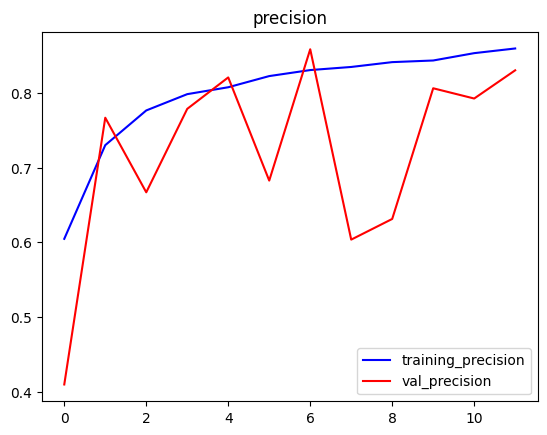

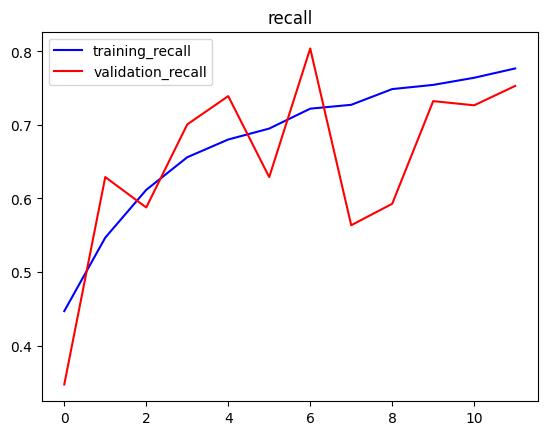

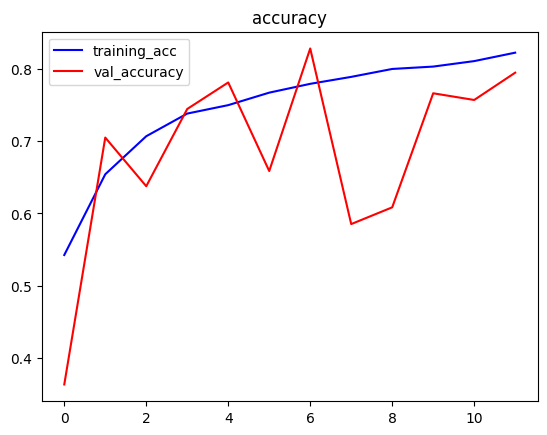

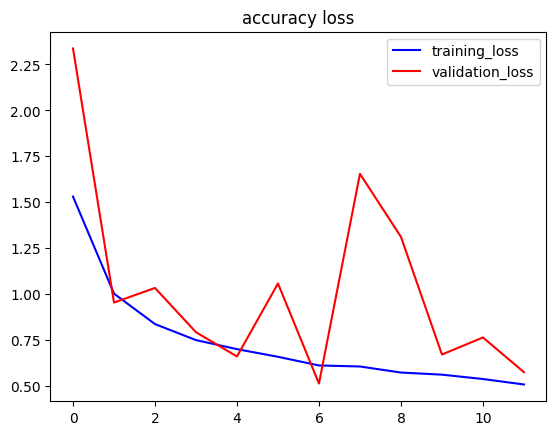

<Figure size 640x480 with 0 Axes>

In [13]:
# ploting graph of scores

acc = history.history['precision']
val_acc = history.history['val_precision']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='training_precision')
plt.plot(epochs, val_acc, 'r', label='val_precision')
plt.title('precision')
plt.legend()
plt.figure()

loss =history.history['recall']
val_loss = history.history['val_recall']
plt.plot(epochs, loss, 'b', label='training_recall')
plt.plot(epochs, val_loss, 'r', label='validation_recall')
plt.title('recall')
plt.legend()
plt.figure()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='training_acc')
plt.plot(epochs, val_acc, 'r', label='val_accuracy')
plt.title('accuracy')
plt.legend()
plt.figure()

loss =history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss, 'b', label='training_loss')
plt.plot(epochs, val_loss, 'r', label='validation_loss')
plt.title('accuracy loss')
plt.legend()
plt.figure()

## Conclusion
